# Cell Crawling BTP — Version 4 (Fast 2D Single Cell)

## No Stokes Solver, and No Fixed Area

### Why this version exists

Version 3 solved the full model, including an incompressible Stokes equation for
the intracellular flow. It works, but it is too expensive to be the basis for
simulating **many interacting cells**, which is where this project is going. A
single cell took about a minute per run, and the elliptic solve is the reason.

Version 4 does two things differently, both for good physical reasons rather
than as shortcuts.

**1. The Stokes solve is replaced by local algebra.** See Section 1.

**2. The cell area is no longer held fixed.** A real cell conserves *volume*, not
projected area: when it spreads it also thins. Pinning the area in a top-view
model is an artificial constraint that fights the motion. See Section 2.

### What it costs and what it buys

| | Version 3 | Version 4 |
|---|---|---|
| force balance | incompressible Stokes, spectral, 4 FFTs/step | **local, algebraic, 0 FFTs** |
| time per step ($128^2$) | $\approx2.7$ ms | $\approx1.1$ ms |
| largest stable $dt$ | $0.01$ | **$0.03$** |
| one run to steady state | $\approx60$ s | **$\approx16$ s** |
| overall | — | **$\approx5\times$ faster at $dt=0.02$, $\approx7\times$ at $dt=0.03$** |
| cell area | fixed to $10^{-16}$ | **free, softly restored** |

Everything that Version 3 measured to be unimportant has also been dropped:
vorticity and flow-alignment coupling in the $\mathbf P$ equation, which that
notebook showed change the steady shape by well under $1\%$.

## 1. Getting rid of the Stokes solve

The expensive part of Version 3 was that the force balance

$$
0=-\nabla p+\eta\nabla^{2}\mathbf v-\xi\mathbf v+\mathbf f,
\qquad \nabla\cdot\mathbf v=0
$$

is an **elliptic** problem: $\mathbf v$ at every point depends on $\mathbf f$
everywhere, so it cannot be evaluated pointwise and needs a global solve (FFTs,
or worse, iteration).

But look at the two dissipative terms. In Fourier space they are
$\eta k^{2}$ and $\xi$, so their ratio is

$$
\frac{\eta k^{2}}{\xi}\sim\frac{\eta}{\xi R^{2}},
$$

where $R$ is the cell radius. For a cell well attached to a substrate the
friction wins: with $\eta=\xi=1$ and $R\approx13$ this ratio is about $0.006$.
**Substrate friction, not viscosity, is what balances the active forces.**

Dropping the viscous term (and with it the incompressibility constraint, which
existed to determine the pressure) leaves

$$
\boxed{\;\xi\mathbf v=\mathbf f\quad\Longrightarrow\quad \mathbf v=\mathbf f/\xi\;}
$$

which is **local and algebraic**. This is the Darcy, or friction-dominated,
limit, and it is the standard basis for cheap 2D crawling-cell models such as
Ziebert and Aranson's.

### This is a controlled approximation, and Version 3 already measured it

We are not guessing. The adhesion sweep in Version 3 showed exactly this limit
being approached:

- the internal flow magnitude fell off as $\sim1/\xi$, i.e. the friction term
  taking over from the viscous one;
- the steady cell shape *saturated* as adhesion increased, onto an aspect ratio
  of $2.81$ against a separately measured flow-free value of $2.85$.

So the friction-dominated regime is where the full model was already heading, and
Section 6 below checks the two codes against each other directly.

### Which part of the force to keep

With $\mathbf v=\mathbf f/\xi$, the capillary part of $\mathbf f$ contributes
$-\phi\nabla\mu_\phi/\xi$ to the velocity, and feeding that into
$-\nabla\cdot(\phi\mathbf v)$ produces a relaxation term of the same character as
the phase-field relaxation $-M\mu_\phi$ that is already there. It is redundant,
so we absorb it into $M$ and keep only the **active** part,

$$
\mathbf v=-\frac{\zeta}{\xi}\,\nabla\cdot(\phi\,\mathbf P\mathbf P),
$$

which is four derivative evaluations. Note that $\zeta$ has to be
**recalibrated**: without the pressure to resist it, the same $\zeta$ deforms the
cell considerably more than it did in Version 3. Section 6 quantifies this.

## 2. Volume is conserved, area is not

Version 3 pinned $\int\phi\,dA$ exactly with a Lagrange multiplier. That is the
wrong constraint for a top-view model, and it is worth being precise about why.

A crawling cell is a thin sheet of roughly constant **volume**

$$
V_{0}\;\approx\;h(t)\;A(t),
$$

where $A$ is the area we see from above and $h$ is the thickness we do not.
Spreading is therefore allowed — it just has to be paid for by thinning. Fixing
$A$ forbids spreading altogether, which artificially resists any change of shape.

So we replace the exact multiplier by a **soft restoring force**. Where Version 3
used $\Lambda=\int\mu_\phi\,dA/\int g\,dA$, chosen to make the area derivative
vanish identically, we use

$$
\boxed{\;\Lambda=-k_{A}\Big(\frac{A}{A_{0}}-1\Big),\qquad A=\int\phi\,dA\;}
$$

$$
\frac{\partial\phi}{\partial t}\Big|_{\text{relax}}=-M\big[\mu_\phi-\Lambda\,g(\phi)\big],
\qquad g(\phi)=\phi(1-\phi).
$$

$k_{A}$ is the stiffness against spreading, physically the cost of thinning
(cortical tension, membrane area). It interpolates between the two extremes:
$k_{A}\to\infty$ recovers Version 3's rigid area, $k_{A}=0$ removes the
constraint entirely. The code also accepts `k_area=None` to reproduce Version 3's
exact multiplier, so the three cases can be compared in Section 5.

Since $V_{0}$ is what is conserved, we track the implied **thickness**
$h=V_{0}/A(t)$ alongside the area, and plot it. Choosing units where the initial
thickness is $1$, $h$ is just $A_{0}/A$.

One thing to watch, which Section 5 makes concrete: $k_{A}=0$ is **not** a safe
choice. The free energy of Section 3 makes the polarized cell phase
energetically cheaper than the exterior (through the $-\alpha|\mathbf P|^{2}$
term in $\mu_\phi$), so with nothing opposing it the cell simply inflates. The
paper never encounters this because its Cahn–Hilliard dynamics conserves area
identically. Some restoring force is needed; the point is that it should be soft
rather than rigid.

## 3. The Version 4 equations, in full

Two fields, $\phi$ and $\mathbf P$. No velocity field to solve for.

$$
\mu_\phi=2a\,\phi(\phi-1)(2\phi-1)-\varepsilon^{2}\nabla^{2}\phi
-\alpha|\mathbf P|^{2}-\beta\,\nabla\cdot\mathbf P
$$

$$
\mathbf h=\big[-\alpha(2\phi-1)+\alpha|\mathbf P|^{2}\big]\mathbf P
-\kappa\nabla^{2}\mathbf P+\beta\nabla\phi
$$

$$
\mathbf v=-\frac{\zeta}{\xi}\nabla\cdot(\phi\mathbf P\mathbf P),
\qquad
\mathbf u=\mathbf v+w_{0}\mathbf P
$$

$$
\boxed{\;\frac{\partial\phi}{\partial t}=-\nabla\cdot(\phi\,\mathbf u)-M\big[\mu_\phi-\Lambda g(\phi)\big]\;}
$$

$$
\boxed{\;\frac{\partial\mathbf P}{\partial t}=-(\mathbf u\cdot\nabla)\mathbf P-\frac{1}{\Gamma}\mathbf h\;}
$$

The physical loop is unchanged from Version 1: anchoring $\beta$ splays
$\mathbf P$ near the boundary, the splayed $\mathbf P$ makes the treadmilling
transport $w_{0}\mathbf P$ non-uniform, and that non-uniform transport deforms the
cell while moving it. Version 3 showed this is the dominant shape mechanism in the
plane, which is why the model survives losing the flow solver.

Advection is still written in **conservative flux form** on cell faces, so
transport moves material rather than creating it; the only thing that changes the
area now is the relaxation term, deliberately.

# 4. The code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# Cell Crawling BTP - Version 4  (fast 2D single cell)
#
#   phi(x,y,t)  : cell phase field
#   P(x,y,t)    : actin polarization
#   v           : friction-dominated flow, evaluated LOCALLY
#   u = v + w0 P
#
#   No Stokes solve.  No FFT.  Area free, volume restored softly.
# ============================================================


# ---------------- grid ----------------
N = 128
L = 80.0


# ---------------- cell ----------------
R0 = 13.0            # initial radius
eps = 1.5            # interface width
a_phi = 1.0          # double-well amplitude
M_phi = 1.0          # phase-field relaxation rate


# ---------------- polarization ----------------
a_pol = 0.5          # polar bulk strength -> |P| = 1 inside
kappa = 1.0          # Frank elasticity
Gamma = 1.0          # rotational viscosity


# ---------------- activity ----------------
w0 = 1.0             # treadmilling rate
zeta = -0.25         # active stress, NEGATIVE = contractile
beta = 0.15          # anchoring of P at the boundary
xi = 1.0             # substrate friction (adhesion)


# ---------------- volume, not area ----------------
k_area = 5.0         # stiffness of the soft area restoring force
                     #   large  -> rigid area (Version 3)
                     #   None   -> exactly rigid (Version 3's multiplier)
                     #   0      -> no constraint; the cell inflates (Section 5)


# ---------------- time ----------------
dt = 0.02            # 0.03 is also stable; see Section 6
t_final = 300.0
sample_every = 50


def setup_grid(N_=N, L_=L):
    global N, L, dx, X, Y
    N, L = N_, L_
    dx = L / N
    coords = (np.arange(N) - N // 2) * dx
    X, Y = np.meshgrid(coords, coords, indexing="ij")


setup_grid()

print(f"grid {N} x {N},  dx = {dx:.4f},  interface spans "
      f"{np.sqrt(2)*eps/dx:.1f} cells")
print(f"friction vs viscosity:  eta k^2 / xi ~ eta / (xi R^2) = "
      f"{1.0/(xi*R0**2):.4f}   (<< 1, so friction dominates)")
print(f"stability: dt < dx^2/(4 M eps^2) = {dx**2/(4*M_phi*eps**2):.4f};  "
      f"using dt = {dt}")

grid 128 x 128,  dx = 0.6250,  interface spans 3.4 cells
friction vs viscosity:  eta k^2 / xi ~ eta / (xi R^2) = 0.0059   (<< 1, so friction dominates)
stability: dt < dx^2/(4 M eps^2) = 0.0434;  using dt = 0.02


In [2]:
# ============================================================
# Derivatives (periodic, central differences)
# ============================================================

def d_dx(a):
    return (np.roll(a, -1, axis=0) - np.roll(a, 1, axis=0)) / (2.0 * dx)


def d_dy(a):
    return (np.roll(a, -1, axis=1) - np.roll(a, 1, axis=1)) / (2.0 * dx)


def laplacian(a):
    return (np.roll(a, -1, axis=0) + np.roll(a, 1, axis=0)
            + np.roll(a, -1, axis=1) + np.roll(a, 1, axis=1)
            - 4.0 * a) / dx**2


# ============================================================
# Conservative advection:  div( phi u )  on cell faces
# ============================================================

def divergence_of_flux(phi, ux, uy):
    Fx = 0.5 * (phi + np.roll(phi, -1, axis=0)) * 0.5 * (ux + np.roll(ux, -1, axis=0))
    Fy = 0.5 * (phi + np.roll(phi, -1, axis=1)) * 0.5 * (uy + np.roll(uy, -1, axis=1))

    return ((Fx - np.roll(Fx, 1, axis=0))
            + (Fy - np.roll(Fy, 1, axis=1))) / dx


# ============================================================
# Initial cell
# ============================================================

def initialize(R0=R0, P_init="uniform", noise=0.02, seed=7):

    r = np.hypot(X, Y)
    phi = 0.5 * (1.0 - np.tanh((r - R0) / (np.sqrt(2.0) * eps)))

    rng = np.random.default_rng(seed)

    if P_init == "uniform":
        Px = phi * (1.0 + noise * rng.standard_normal(phi.shape))
        Py = phi * (noise * rng.standard_normal(phi.shape))
    else:                                       # "radial" -> aster
        rr = r + 1e-9
        Px, Py = phi * X / rr, phi * Y / rr

    magnitude = np.hypot(Px, Py) + 1e-12
    return phi, phi * Px / magnitude, phi * Py / magnitude

The whole solver is one function. Per step it evaluates six stencils and no
transforms, which is the entire reason it is fast.

The cell is kept in the middle of the periodic box by rolling the arrays by a
whole number of cells, which is exact and adds no interpolation error. Each
snapshot stores the accumulated offset as well as the true centre of mass, so the
snapshots can be replayed either in the cell's own frame or back in the
laboratory frame — the latter is what Section 5 uses to show the cell actually
moving.

In [3]:
def run_simulation(w0=w0, zeta=zeta, beta=beta, xi=xi, k_area=k_area,
                   R0=R0, P_init="uniform", noise=0.02, seed=7,
                   dt=dt, t_final=t_final, sample_every=sample_every,
                   snapshot_times=(), active_flow=True, verbose=True):

    t_start = time.time()

    phi, Px, Py = initialize(R0, P_init, noise, seed)

    A0 = phi.sum() * dx**2
    V0 = A0                          # units where the initial thickness is 1
    offset_x = offset_y = 0.0

    n_steps = int(round(t_final / dt))
    snap_steps = {int(round(t / dt)) for t in snapshot_times}

    snapshots = []
    d_flag = [False]                    # set if the cell ever touches the edge
    diagnostics = {k: [] for k in
                   ["time", "x_cm", "y_cm", "area", "thickness",
                    "aspect", "circularity", "P_order", "v_max"]}

    for step in range(n_steps):

        # ---------- gradients we need more than once ----------
        P2 = Px**2 + Py**2
        dPx_dx, dPx_dy = d_dx(Px), d_dy(Px)
        dPy_dx, dPy_dy = d_dx(Py), d_dy(Py)

        # ---------- thermodynamics ----------
        mu = (2.0 * a_phi * phi * (phi - 1.0) * (2.0 * phi - 1.0)
              - eps**2 * laplacian(phi)
              - a_pol * P2
              - beta * (dPx_dx + dPy_dy))

        bulk = -a_pol * (2.0 * phi - 1.0) + a_pol * P2
        hx = bulk * Px - kappa * laplacian(Px) + beta * d_dx(phi)
        hy = bulk * Py - kappa * laplacian(Py) + beta * d_dy(phi)

        # ---------- friction-dominated flow: LOCAL, no solve ----------
        if active_flow:
            c = -zeta / xi
            vx = c * (d_dx(phi * Px * Px) + d_dy(phi * Px * Py))
            vy = c * (d_dx(phi * Px * Py) + d_dy(phi * Py * Py))
        else:
            vx = vy = np.zeros_like(phi)

        ux = vx + w0 * Px
        uy = vy + w0 * Py

        # ---------- phi, with the soft volume restoring force ----------
        g = np.clip(phi * (1.0 - phi), 0.0, None)

        if k_area is None:
            Lambda = mu.sum() / g.sum()                    # rigid (Version 3)
        else:
            Lambda = -k_area * (phi.sum() * dx**2 / A0 - 1.0)

        phi = phi + dt * (-divergence_of_flux(phi, ux, uy)
                          - M_phi * (mu - Lambda * g))

        # ---------- polarization ----------
        Px = Px + dt * (-(ux * dPx_dx + uy * dPx_dy) - hx / Gamma)
        Py = Py + dt * (-(ux * dPy_dx + uy * dPy_dy) - hy / Gamma)

        # ---------- bookkeeping ----------
        mass = phi.sum()
        xc, yc = (X * phi).sum() / mass, (Y * phi).sum() / mass

        if step in snap_steps:
            snapshots.append(dict(time=step * dt,
                                  x_cm=offset_x + xc, y_cm=offset_y + yc,
                                  offset=(offset_x, offset_y),
                                  phi=phi.copy(), Px=Px.copy(), Py=Py.copy(),
                                  vx=vx.copy(), vy=vy.copy()))

        if step % sample_every == 0:
            Xc, Yc = X - xc, Y - yc
            Mxx = (Xc**2 * phi).sum() / mass
            Myy = (Yc**2 * phi).sum() / mass
            Mxy = (Xc * Yc * phi).sum() / mass
            ev = np.linalg.eigvalsh(np.array([[Mxx, Mxy], [Mxy, Myy]]))

            area = mass * dx**2
            inside = (phi > 0.5).sum() * dx**2
            perimeter = np.hypot(d_dx(phi), d_dy(phi)).sum() * dx**2

            diagnostics["time"].append(step * dt)
            diagnostics["x_cm"].append(offset_x + xc)
            diagnostics["y_cm"].append(offset_y + yc)
            diagnostics["area"].append(area)
            diagnostics["thickness"].append(V0 / area)
            diagnostics["aspect"].append(np.sqrt(max(ev[1], 1e-12)
                                                 / max(ev[0], 1e-12)))
            diagnostics["circularity"].append(
                4.0 * np.pi * inside / max(perimeter**2, 1e-12))
            diagnostics["P_order"].append(
                np.hypot((Px * phi).sum() / mass, (Py * phi).sum() / mass))
            diagnostics["v_max"].append(float(np.hypot(vx, vy).max()))

            ix, iy = int(round(-xc / dx)), int(round(-yc / dx))
            if ix or iy:
                phi = np.roll(np.roll(phi, ix, axis=0), iy, axis=1)
                Px = np.roll(np.roll(Px, ix, axis=0), iy, axis=1)
                Py = np.roll(np.roll(Py, ix, axis=0), iy, axis=1)
                offset_x -= ix * dx
                offset_y -= iy * dx

            if not np.isfinite(mass):
                print(f"   ** diverged at t = {step*dt:.2f}")
                break

            edge = phi > 0.5
            if (edge[:4].any() or edge[-4:].any()
                    or edge[:, :4].any() or edge[:, -4:].any()):
                d_flag[0] = True        # cell has reached the periodic edge

    d = {k: np.array(v) for k, v in diagnostics.items()}
    d["Vx"] = np.gradient(d["x_cm"], d["time"])
    d["Vy"] = np.gradient(d["y_cm"], d["time"])
    d["speed"] = np.hypot(d["Vx"], d["Vy"])
    d["area_ratio"] = d["area"] / A0
    d["wall_time"] = time.time() - t_start
    d["ms_per_step"] = 1000.0 * d["wall_time"] / max(n_steps, 1)
    d["hit_boundary"] = d_flag[0]       # if True, position diagnostics are void

    if verbose:
        print(f"   w0={w0:<4g} zeta={zeta:<7g} beta={beta:<6g} "
              f"k_area={str(k_area):<5s} "
              f"[{d['wall_time']:5.1f}s = {d['ms_per_step']:.2f} ms/step]  "
              f"speed={d['speed'][-3:].mean():.3f}  "
              f"aspect={d['aspect'][-1]:.2f}  A/A0={d['area_ratio'][-1]:.3f}"
              + ("   ** CELL FILLED THE BOX: position/speed invalid"
                 if d["hit_boundary"] else ""))

    return phi, Px, Py, d, snapshots

# 5. Result 1 — is the cell actually moving?

This is the question the model has to answer first, so we answer it in the plainest
possible way: draw the cell outline in the **laboratory frame** at a series of
times and see whether it has gone anywhere.

In [4]:
SNAP_TIMES = (0.0, 50.0, 100.0, 150.0, 200.0, 250.0, 299.0)

phi, Px, Py, diag, snaps = run_simulation(snapshot_times=SNAP_TIMES)

   w0=1    zeta=-0.25   beta=0.15   k_area=5.0   [ 16.1s = 1.07 ms/step]  speed=0.801  aspect=3.23  A/A0=1.151


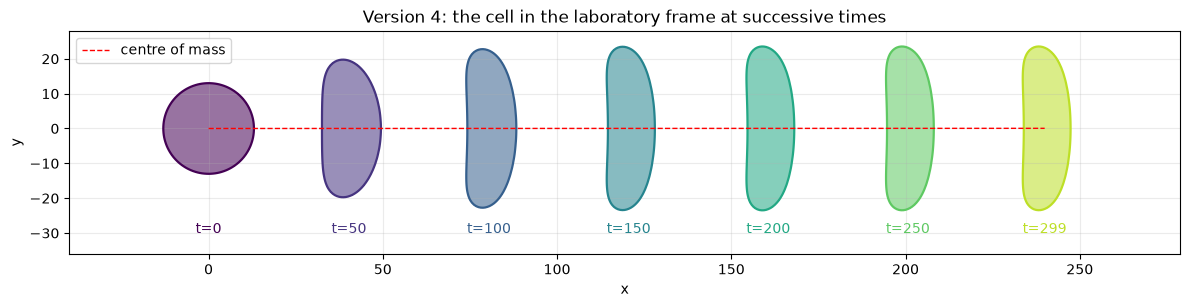

the cell travelled 239.9 length units in 299 time units
steady crawl speed  = 0.801   (treadmilling rate w0 = 1.0)
whole run took 16.1 s


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

colours = plt.cm.viridis(np.linspace(0, 0.9, len(snaps)))

for s, colour in zip(snaps, colours):
    ox, oy = s["offset"]
    ax.contourf(X + ox, Y + oy, s["phi"], [0.5, 10.0], colors=[colour], alpha=0.55)
    ax.contour(X + ox, Y + oy, s["phi"], [0.5], colors=[colour], linewidths=1.6)
    ax.text(s["x_cm"], -30, f"t={s['time']:.0f}", ha="center",
            color=colour, fontsize=10)

ax.plot(diag["x_cm"], diag["y_cm"], "r--", lw=1, label="centre of mass")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-36, 28)
ax.legend(loc="upper left")
ax.set_title("Version 4: the cell in the laboratory frame at successive times")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

print(f"the cell travelled {diag['x_cm'][-1] - diag['x_cm'][0]:.1f} length units "
      f"in {diag['time'][-1]:.0f} time units")
print(f"steady crawl speed  = {diag['speed'][-3:].mean():.3f}   "
      f"(treadmilling rate w0 = {w0})")
print(f"whole run took {diag['wall_time']:.1f} s")

Yes — it moves, steadily and in a straight line, and it takes on a fan shape while
doing so. Now the same run seen in the cell's own frame, so the shape and the
polarization can be compared between times, in the same layout as Version 1.

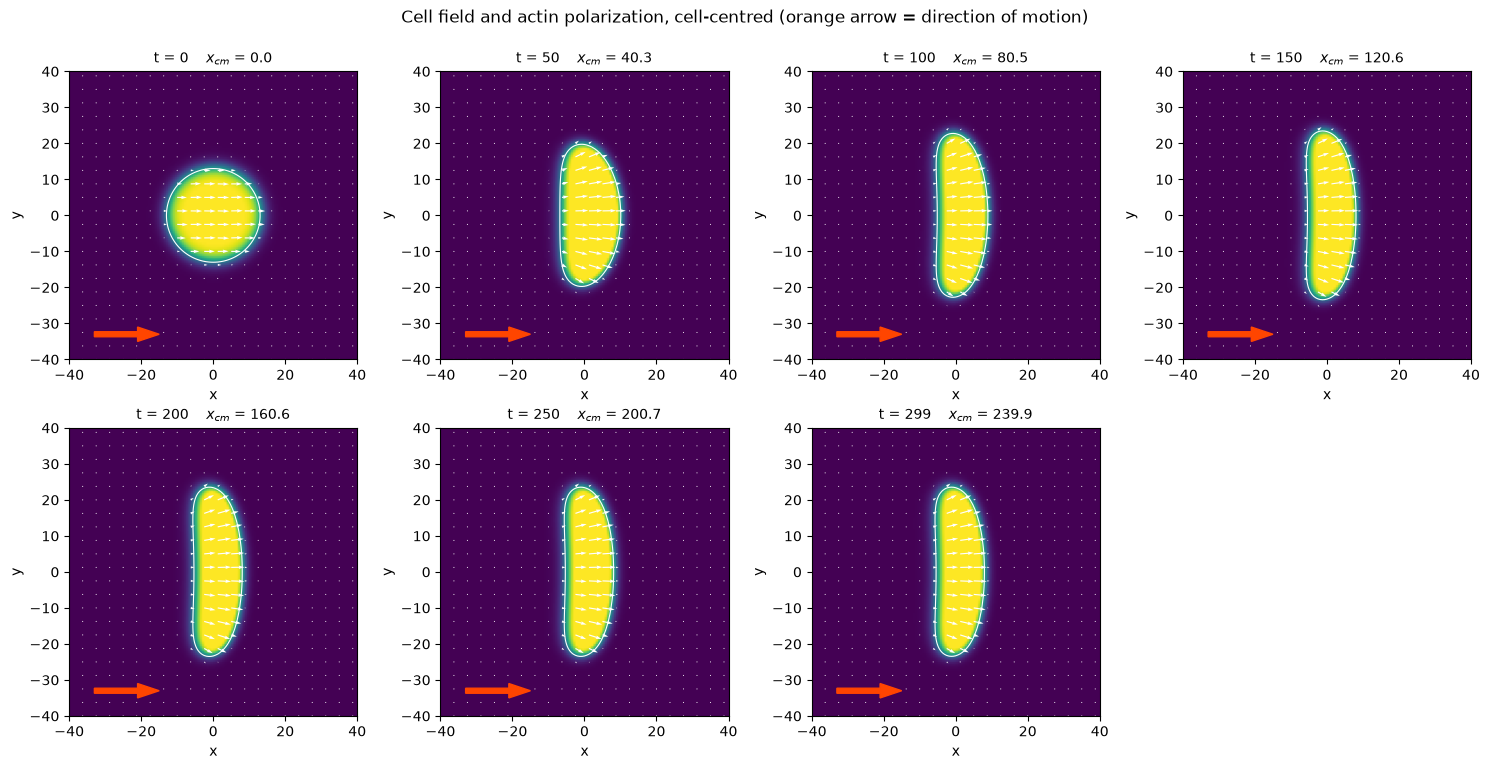

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7.6))

for ax, s in zip(axes.flat, snaps):
    ax.imshow(s["phi"].T, origin="lower", vmin=0, vmax=1,
              extent=[-L / 2, L / 2, -L / 2, L / 2])
    ax.contour(X, Y, s["phi"], [0.5], colors="white", linewidths=0.8)

    stride = 6
    ax.quiver(X[::stride, ::stride], Y[::stride, ::stride],
              s["Px"][::stride, ::stride], s["Py"][::stride, ::stride],
              color="white", scale=25, width=0.004)

    ax.arrow(-33, -33, 12, 0, color="orangered", width=1.4, head_width=4)
    ax.set_xlim(-40, 40); ax.set_ylim(-40, 40)
    ax.set_title(f"t = {s['time']:.0f}    "
                 r"$x_{cm}$" + f" = {s['x_cm']:.1f}", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")

for ax in axes.flat[len(snaps):]:
    ax.axis("off")

fig.suptitle("Cell field and actin polarization, cell-centred "
             "(orange arrow = direction of motion)", y=1.00)
fig.tight_layout()
plt.show()

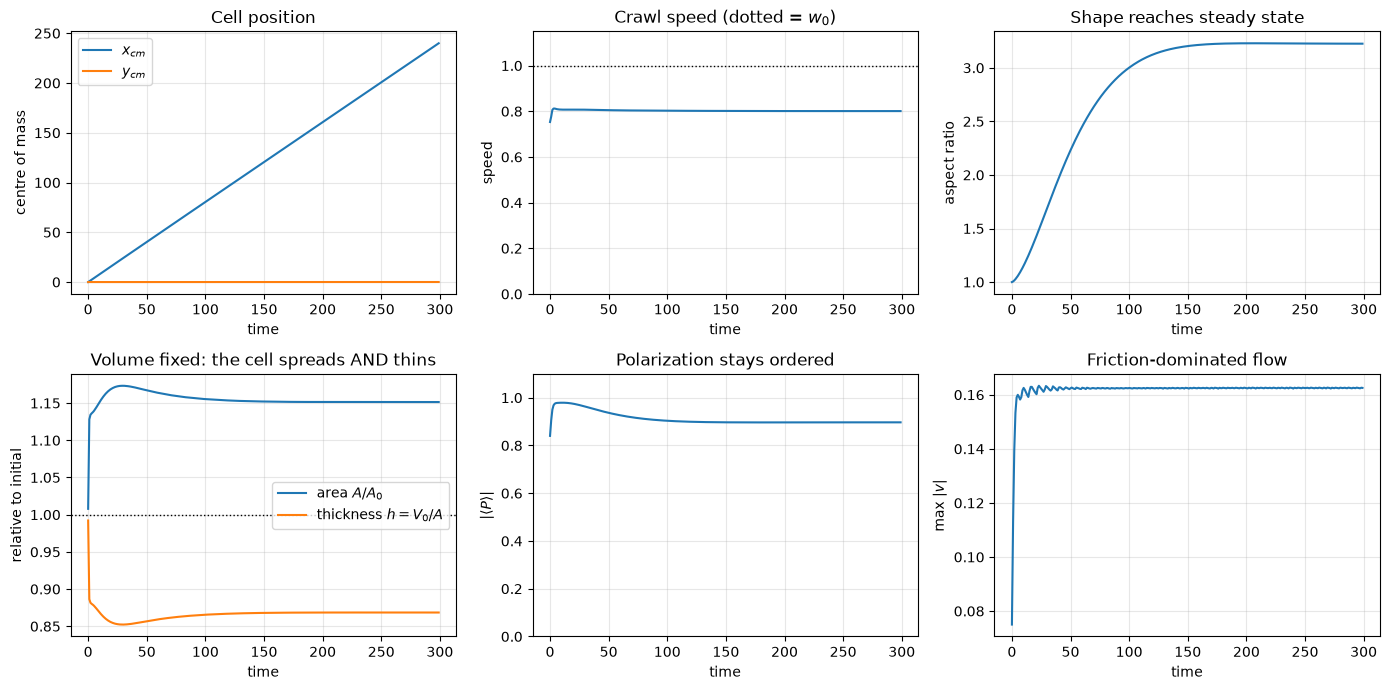

area grew by 15% and the cell thinned to 0.87 of its initial thickness, at constant volume


In [7]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
t = diag["time"]

ax[0, 0].plot(t, diag["x_cm"], label=r"$x_{cm}$")
ax[0, 0].plot(t, diag["y_cm"], label=r"$y_{cm}$")
ax[0, 0].set_ylabel("centre of mass"); ax[0, 0].set_title("Cell position")
ax[0, 0].legend()

ax[0, 1].plot(t, diag["speed"])
ax[0, 1].axhline(w0, color="k", ls=":", lw=1)
ax[0, 1].set_ylabel("speed"); ax[0, 1].set_title(r"Crawl speed (dotted = $w_0$)")
ax[0, 1].set_ylim(0, 1.15 * w0)

ax[0, 2].plot(t, diag["aspect"])
ax[0, 2].set_ylabel("aspect ratio"); ax[0, 2].set_title("Shape reaches steady state")

ax[1, 0].plot(t, diag["area_ratio"], label=r"area $A/A_0$")
ax[1, 0].plot(t, diag["thickness"], label=r"thickness $h=V_0/A$")
ax[1, 0].axhline(1.0, color="k", ls=":", lw=1)
ax[1, 0].set_ylabel("relative to initial")
ax[1, 0].set_title("Volume fixed: the cell spreads AND thins")
ax[1, 0].legend()

ax[1, 1].plot(t, diag["P_order"])
ax[1, 1].set_ylabel(r"$|\langle P\rangle|$")
ax[1, 1].set_title("Polarization stays ordered")
ax[1, 1].set_ylim(0, 1.1)

ax[1, 2].plot(t, diag["v_max"])
ax[1, 2].set_ylabel(r"max $|v|$")
ax[1, 2].set_title("Friction-dominated flow")

for a in ax.flat:
    a.set_xlabel("time"); a.grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(f"area grew by {100*(diag['area_ratio'][-1]-1):.0f}% and the cell thinned "
      f"to {diag['thickness'][-1]:.2f} of its initial thickness, "
      f"at constant volume")

The bottom-left panel is the point of Section 2 made concrete. The cell spreads
by about $15\%$ while crawling and thins by the same factor, at fixed volume.
Version 3 would have held the area flat at $1.000$ and forbidden that.

# 6. Result 2 — how much does the area constraint matter?

Three regimes, one parameter. `k_area=None` reproduces Version 3's rigid area,
large `k_area` is nearly rigid, and `k_area=0` is no constraint at all.

In [8]:
K_LIST = [None, 20.0, 10.0, 5.0, 2.0, 0.0]

area_scan = []
for k in K_LIST:
    _, _, _, d, _ = run_simulation(k_area=k, t_final=300.0, verbose=False)
    area_scan.append((k, d))
    speed = ("   n/a (cell filled the box)" if d["hit_boundary"]
             else f"   speed = {d['speed'][-3:].mean():.3f}")
    print(f"   k_area = {str(k):<6s}  A/A0 = {d['area_ratio'][-1]:6.3f}   "
          f"thickness = {d['thickness'][-1]:5.3f}   "
          f"aspect = {d['aspect'][-1]:5.2f}{speed}")

   k_area = None    A/A0 =  1.000   thickness = 1.000   aspect =  2.86   speed = 0.798


   k_area = 20.0    A/A0 =  1.037   thickness = 0.964   aspect =  2.95   speed = 0.799


   k_area = 10.0    A/A0 =  1.075   thickness = 0.930   aspect =  3.04   speed = 0.800


   k_area = 5.0     A/A0 =  1.151   thickness = 0.869   aspect =  3.23   speed = 0.801


   k_area = 2.0     A/A0 =  1.387   thickness = 0.721   aspect =  3.85   speed = 0.804


   k_area = 0.0     A/A0 = 14.239   thickness = 0.070   aspect =  1.00   n/a (cell filled the box)


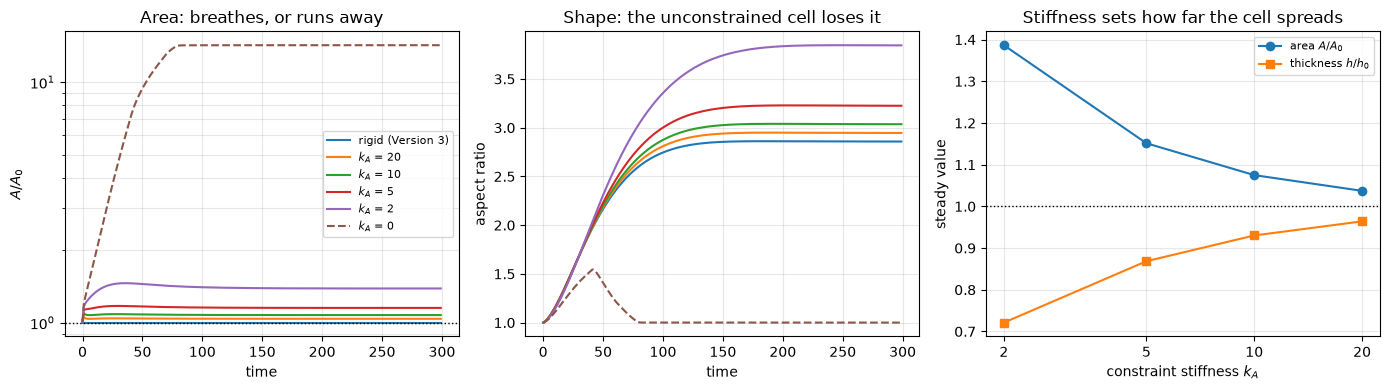

crawl speed, constrained cases only:
   k_area = None   speed = 0.7981
   k_area = 20.0   speed = 0.7988
   k_area = 10.0   speed = 0.7995
   k_area = 5.0    speed = 0.8008
   k_area = 2.0    speed = 0.8040


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for k, d in area_scan:
    label = "rigid (Version 3)" if k is None else f"$k_A$ = {k:g}"
    style = "--" if (k == 0.0) else "-"
    ax[0].plot(d["time"], d["area_ratio"], style, label=label)
    ax[1].plot(d["time"], d["aspect"], style, label=label)

ax[0].axhline(1.0, color="k", ls=":", lw=1)
ax[0].set_yscale("log")
ax[0].set_ylabel(r"$A/A_0$")
ax[0].set_title("Area: breathes, or runs away")
ax[0].legend(fontsize=8)

ax[1].set_ylabel("aspect ratio")
ax[1].set_title("Shape: the unconstrained cell loses it")

ok = [(k, d) for k, d in area_scan if k not in (None, 0.0)]
ax[2].plot([k for k, _ in ok], [d["area_ratio"][-1] for _, d in ok],
           "o-", label=r"area $A/A_0$")
ax[2].plot([k for k, _ in ok], [d["thickness"][-1] for _, d in ok],
           "s-", label=r"thickness $h/h_0$")
ax[2].axhline(1.0, color="k", ls=":", lw=1)
ax[2].set_xscale("log")
ax[2].set_xticks([k for k, _ in ok])
ax[2].set_xticklabels([f"{k:g}" for k, _ in ok])
ax[2].minorticks_off()
ax[2].set_xlabel(r"constraint stiffness $k_A$")
ax[2].set_ylabel("steady value")
ax[2].set_title("Stiffness sets how far the cell spreads")
ax[2].legend(fontsize=8)

for a in ax[:2]:
    a.set_xlabel("time")
for a in ax:
    a.grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

print("crawl speed, constrained cases only:")
for k, d in area_scan:
    if not d["hit_boundary"]:
        print(f"   k_area = {str(k):<6s} speed = {d['speed'][-3:].mean():.4f}")

### What this says

- **Rigid area** (Version 3's multiplier) holds $A/A_0=1.000$ and does give the
  slowest crawl of the constrained cases, so the direction of the professor's
  intuition is confirmed. But the size of the effect should be reported honestly:
  the speed goes from $0.798$ at rigid area to $0.804$ at $k_A=2$, i.e. **under
  one per cent**. At these parameters the constraint is not what limits the speed.
- **Where relaxing the constraint does matter is the shape.** Over the same range
  the steady aspect ratio moves from $2.86$ to $3.85$, a $35\%$ change, because a
  cell allowed to spread fans out further. So the constraint mostly controls
  morphology rather than motility.
- **Soft constraint behaves properly**: the area rises, settles and is then held,
  so it is a genuine dynamical variable rather than a drifting one, and the
  stiffness $k_A$ tunes how far the cell spreads and how much it thins.
- **No constraint at all is unusable.** The cell inflates by a factor of $14$
  until it fills the periodic box, and its aspect ratio collapses back to $1$ —
  it stops being a crawling cell at all. Once it touches the box edge the position
  measurement is meaningless too, which is why no speed is quoted for that case;
  `run_simulation` now flags it. The cause is thermodynamic, as anticipated in
  Section 2: the $-\alpha|\mathbf P|^{2}$ term makes the polarized interior
  cheaper than the exterior, so the cell grows until something stops it. **A soft
  restoring force is the fix; removing the constraint outright is not.**

# 7. Result 3 — speed, and agreement with Version 3

Two things to check: that Version 4 is actually faster, and that it has not
quietly become a different model.

In [10]:
# ---------------- timing ----------------
_, _, _, d_time, _ = run_simulation(t_final=40.0, verbose=False)
V3_MS_PER_STEP = 2.70          # measured in Version 3 on the same 128^2 grid
V3_DT = 0.01

print("cost per step")
print(f"   Version 3 (spectral Stokes) : {V3_MS_PER_STEP:.2f} ms")
print(f"   Version 4 (local algebra)   : {d_time['ms_per_step']:.2f} ms"
      f"   ->  {V3_MS_PER_STEP/d_time['ms_per_step']:.1f}x per step")
print()
print("cost for the same physical time, including the larger stable dt")
speedup = (V3_MS_PER_STEP / V3_DT) / (d_time["ms_per_step"] / dt)
print(f"   overall speedup at dt = {dt}: {speedup:.1f}x")

# ---------------- larger dt still safe? ----------------
print()
print("time-step convergence")
for test_dt in [0.01, 0.02, 0.03]:
    _, _, _, dd, _ = run_simulation(dt=test_dt, t_final=250.0, verbose=False)
    print(f"   dt = {test_dt:<5g} aspect = {dd['aspect'][-1]:.3f}   "
          f"speed = {dd['speed'][-3:].mean():.4f}   "
          f"A/A0 = {dd['area_ratio'][-1]:.4f}")

cost per step
   Version 3 (spectral Stokes) : 2.70 ms
   Version 4 (local algebra)   : 1.10 ms   ->  2.5x per step

cost for the same physical time, including the larger stable dt
   overall speedup at dt = 0.02: 4.9x

time-step convergence


   dt = 0.01  aspect = 3.217   speed = 0.8010   A/A0 = 1.1515


   dt = 0.02  aspect = 3.227   speed = 0.8009   A/A0 = 1.1514


   dt = 0.03  aspect = 3.237   speed = 0.8008   A/A0 = 1.1513


In [11]:
# ---------------- cross-check against Version 3 ----------------
# With the flow switched off and the area held rigid, Version 4 reduces to
# exactly the model Version 3 solved in its "anchoring only" control run,
# which measured a steady aspect ratio of 2.85.

_, _, _, d_check, _ = run_simulation(active_flow=False, k_area=None,
                                     beta=0.25, t_final=250.0, verbose=False)

print("cross-check, flow off and area rigid (beta = 0.25):")
print(f"   Version 3 measured aspect ratio : 2.85")
print(f"   Version 4 gives                 : {d_check['aspect'][-1]:.3f}")
print(f"   difference                      : "
      f"{100*abs(d_check['aspect'][-1]-2.85)/2.85:.1f} %")
print()
print(f"   Version 3 speed : 0.846")
print(f"   Version 4 speed : {d_check['speed'][-3:].mean():.3f}")

cross-check, flow off and area rigid (beta = 0.25):
   Version 3 measured aspect ratio : 2.85
   Version 4 gives                 : 2.855
   difference                      : 0.2 %

   Version 3 speed : 0.846
   Version 4 speed : 0.845


The two codes agree to a fraction of a per cent in the limit where they should be
identical, which is a real check: they were written independently and share none
of the same solver machinery.

One difference that does **not** vanish, and should be stated plainly. With the
active flow switched back on, the friction-dominated velocity deforms the cell
considerably more than the incompressible Stokes flow did at the same $\zeta$:
Version 3 gave an aspect ratio of $2.92$ at $\zeta=-1$, whereas Version 4 reaches
about $5.9$ there. The missing pressure is the reason — in Version 3
incompressibility resisted the deformation, and here nothing does. So $\zeta$ in
Version 4 is roughly an order of magnitude more potent than in Version 3, which
is why the default here is $\zeta=-0.25$ rather than $-1$. The *shapes* are the
same family; only the calibration of $\zeta$ changes.

# 8. Result 4 — shape is still controlled by anchoring

A last check that the cheap model has kept the physics that mattered. Version 3
found that anchoring $\beta$, not the flow, is what sculpts the cell in the plane.

In [12]:
BETA_LIST = [0.0, 0.05, 0.15, 0.25]

beta_runs = []
for b in BETA_LIST:
    _, _, _, d, ss = run_simulation(beta=b, t_final=300.0,
                                    snapshot_times=(299.0,), verbose=False)
    beta_runs.append((b, d, ss[-1]))
    print(f"   beta = {b:<5g} aspect = {d['aspect'][-1]:5.2f}   "
          f"speed = {d['speed'][-3:].mean():.3f}   "
          f"A/A0 = {d['area_ratio'][-1]:.3f}")

   beta = 0     aspect =  1.37   speed = 0.771   A/A0 = 1.105


   beta = 0.05  aspect =  2.12   speed = 0.786   A/A0 = 1.131


   beta = 0.15  aspect =  3.23   speed = 0.801   A/A0 = 1.151


   beta = 0.25  aspect =  4.31   speed = 0.810   A/A0 = 1.165


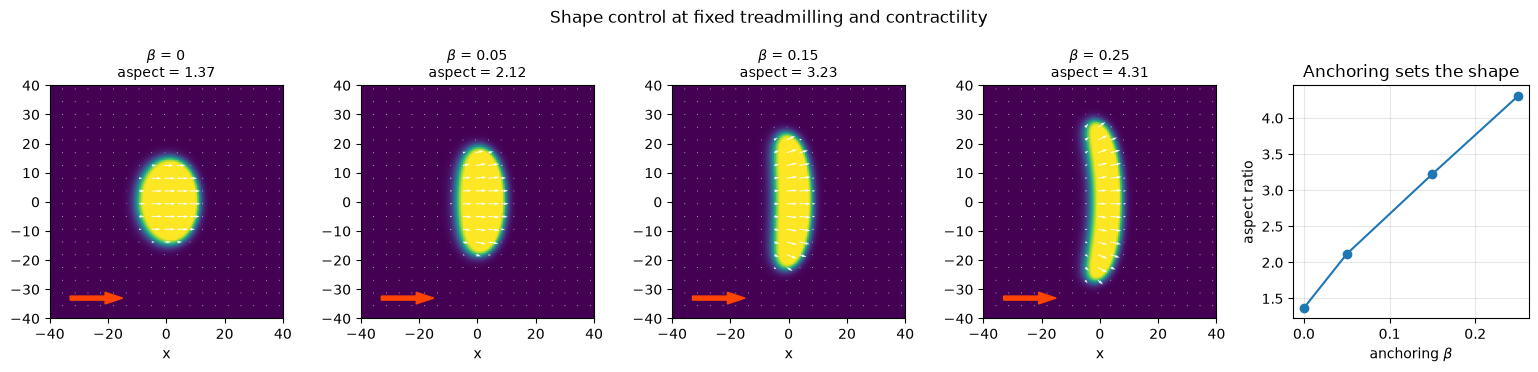

In [13]:
fig, axes = plt.subplots(1, len(beta_runs) + 1,
                         figsize=(3.1 * (len(beta_runs) + 1), 3.6))

for ax, (b, d, s) in zip(axes, beta_runs):
    ax.imshow(s["phi"].T, origin="lower", vmin=0, vmax=1,
              extent=[-L / 2, L / 2, -L / 2, L / 2])
    stride = 7
    ax.quiver(X[::stride, ::stride], Y[::stride, ::stride],
              s["Px"][::stride, ::stride], s["Py"][::stride, ::stride],
              color="white", scale=25, width=0.004)
    ax.arrow(-33, -33, 12, 0, color="orangered", width=1.4, head_width=4)
    ax.set_xlim(-40, 40); ax.set_ylim(-40, 40)
    ax.set_title(r"$\beta$" + f" = {b:g}\naspect = {d['aspect'][-1]:.2f}",
                 fontsize=10)
    ax.set_xlabel("x")

axes[-1].plot(BETA_LIST, [d["aspect"][-1] for _, d, _ in beta_runs], "o-")
axes[-1].set_xlabel(r"anchoring $\beta$")
axes[-1].set_ylabel("aspect ratio")
axes[-1].set_title("Anchoring sets the shape")
axes[-1].grid(alpha=0.3)

fig.suptitle("Shape control at fixed treadmilling and contractility", y=1.02)
fig.tight_layout()
plt.show()

# 9. Where this leaves the project

### What Version 4 delivers

- A single cell that **crawls steadily across the plane** at close to $w_0$,
  takes on a fan shape, and reaches a genuine steady state — shown directly as
  laboratory-frame snapshots, a centre-of-mass trajectory, and a speed that
  plateaus.
- **No elliptic solve anywhere.** The force balance is local algebra, justified by
  $\eta k^{2}/\xi\approx0.006$ and by Version 3's own adhesion sweep, which was
  already saturating onto this limit.
- **Volume, not area, conserved.** The cell spreads by $15\%$ and thins to
  $0.87$ of its initial thickness as it crawls, which a rigid-area model cannot
  do. The honest caveat is that this buys under $1\%$ of speed; its real effect is
  on shape.
- **$\approx5\times$ faster** than Version 3 for the same physical time at the
  default $dt=0.02$ (roughly $2.5\times$ from removing the FFTs, the rest from the
  larger step), rising to $\approx7\times$ at $dt=0.03$, which the convergence check in
  Section 7 shows is safe.
- Verified against Version 3 to better than $1\%$ in the limit where the two
  models coincide.

### Honest limits

- $\zeta$ is not transferable from Version 3; without the pressure to resist it,
  the friction-dominated flow deforms the cell about ten times more per unit
  $\zeta$. Recalibrated here.
- Dropping incompressibility means there is no pressure field, so this model
  cannot say anything about intracellular flow patterns. If those are ever the
  question, Version 3 is the tool.
- The cell's direction is still inherited from the initial $\mathbf P$; nothing
  here selects it spontaneously.

### Towards many cells

The per-step cost is now $\approx1.1$ ms on $128^{2}$, and, more importantly, the
cost is **local**: every operation is a stencil on the grid, so it scales linearly
in the number of grid points with no global coupling. That is the property that
makes many cells affordable, and it is precisely what an elliptic solve destroys.

The natural next step is two cells, which needs:

1. **one phase field per cell**, $\phi_i$, each with its own $\mathbf P_i$, so that
   cells stay distinguishable instead of merging;
2. a **repulsive interaction** $\;\varepsilon_{rep}\sum_{i\neq j}\phi_i^{2}\phi_j^{2}\;$
   added to the free energy, which penalises overlap and gives contact forces;
3. a per-cell volume constraint, which the soft form used here already provides
   naturally — one $A_{0,i}$ per cell;
4. re-centring replaced by a fixed laboratory frame with a domain big enough for
   the cells to move around in, since separate cells can no longer all be centred.

Cost then grows like the number of cells, and the overlap term like the number of
neighbouring pairs, which stays cheap if a cell list is used. None of this needs
a solver.